# **APRENDIZAJE DE LOS DATOS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/train_prepared_pf.csv')
data.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,FullBath,...,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Street_Pave,Alley_Pave,Utilities_NoSeWa,CentralAir_Y
0,60,65.0,8450,7,5,196.0,706.0,150,856.0,2,...,0,0,0,0,1,0,1,0,0,1
1,20,80.0,9600,6,8,0.0,978.0,284,1262.0,2,...,0,0,0,0,1,0,1,0,0,1
2,60,68.0,11250,7,5,162.0,486.0,434,920.0,2,...,0,0,0,0,1,0,1,0,0,1
3,70,60.0,9550,7,5,0.0,216.0,540,756.0,1,...,1,0,0,0,0,0,1,0,0,1
4,60,84.0,14260,8,5,350.0,655.0,490,1145.0,2,...,0,0,0,0,1,0,1,0,0,1


In [ ]:
#Validación Cruzada
from sklearn.model_selection import cross_validate

#Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()
scoring=('neg_mean_absolute_error','neg_mean_absolute_percentage_error','neg_root_mean_squared_error','r2')

cv = 10

<Axes: >

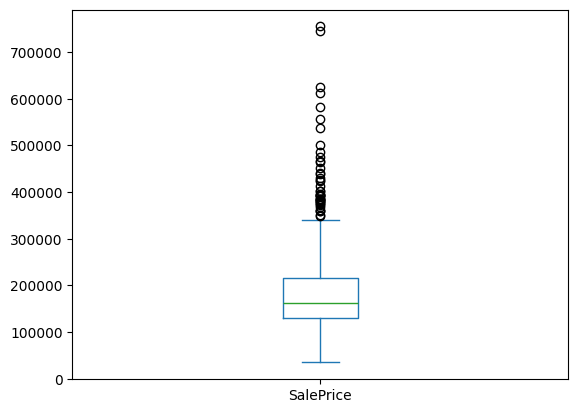

In [ ]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("SalePrice", axis = 1) # Variables predictoras
Y = data['SalePrice'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=None)
Y_train.plot(kind='box')

# **ARBOL DE REGRESION**

In [ ]:
#Método de ML a usar en la validación cruzada
from sklearn import tree
modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=4, max_depth=5,random_state=42)

scores = cross_validate(modelTree, X_train, Y_train, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_r2,train_r2
0,0.028482,0.009116,-27877.627864,-23696.538719,-0.151404,-0.144734,-39975.625144,-32879.145404,0.801231,0.835194
1,0.022134,0.008898,-30649.385785,-23838.457633,-0.192747,-0.143428,-40708.478663,-34287.626480,0.591712,0.832233
2,0.039570,0.008589,-31560.150539,-23307.635582,-0.173438,-0.144243,-45035.432599,-32475.816867,0.642358,0.845522
3,0.021511,0.008144,-31917.702029,-23671.821770,-0.170340,-0.145375,-62503.569464,-32060.041254,0.293551,0.849721
4,0.022959,0.008529,-31875.169163,-23442.378674,-0.200119,-0.141832,-48814.641381,-33356.977857,0.577508,0.836821
5,0.027407,0.023112,-37551.665352,-23208.128562,-0.210950,-0.139027,-58807.489815,-32747.422750,0.610932,0.833595
6,0.041253,0.008188,-36399.508711,-22556.144710,-0.192516,-0.138550,-58451.715568,-31684.368011,0.656226,0.841891
7,0.055223,0.017788,-29037.541897,-23898.588608,-0.166167,-0.144101,-42583.901498,-34837.639846,0.789346,0.813331
8,0.035039,0.008632,-22648.113744,-24482.047648,-0.153948,-0.147720,-28746.850049,-34806.007494,0.733776,0.829092
9,0.032094,0.008600,-28760.663926,-23877.612374,-0.166729,-0.143806,-44977.860050,-34045.084497,0.711855,0.826366


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,0.032567
score_time,0.010960
test_neg_mean_absolute_error,-30827.752901
train_neg_mean_absolute_error,-23597.935428
test_neg_mean_absolute_percentage_error,-0.177836
train_neg_mean_absolute_percentage_error,-0.143282
test_neg_root_mean_squared_error,-47060.556423
train_neg_root_mean_squared_error,-33318.013046
test_r2,0.640850
train_r2,0.834377


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['Tree']=scores['test_r2']
print(comparacion_CV)

       Tree
0  0.801231
1  0.591712
2  0.642358
3  0.293551
4  0.577508
5  0.610932
6  0.656226
7  0.789346
8  0.733776
9  0.711855


# **RANDOM FOREST**

In [ ]:
#Random forest
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, criterion='squared_error', min_samples_leaf=7, max_depth=None, random_state=42)

scores = cross_validate(model_rf, X_train, Y_train, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_r2,train_r2
0,2.457157,0.035805,-21437.035943,-14904.975257,-0.105177,-0.084773,-38792.190298,-26614.353092,0.812826,0.892015
1,3.291958,0.096064,-19768.572300,-15279.137674,-0.122699,-0.084955,-27102.850716,-27600.500764,0.819021,0.891291
2,4.287955,0.027442,-21821.704794,-14683.655841,-0.114600,-0.083473,-33158.562741,-26771.478813,0.806121,0.895024
3,2.501431,0.030529,-23976.198915,-14322.756324,-0.133258,-0.081958,-44323.808407,-24640.571774,0.644741,0.911229
4,2.509549,0.028664,-19583.990038,-14930.691466,-0.121777,-0.083694,-29328.546836,-27259.692031,0.847490,0.891024
5,1.259849,0.015494,-23572.143545,-14849.816481,-0.139746,-0.083225,-37518.631844,-27400.584239,0.841637,0.883498
6,1.178127,0.014415,-26726.285722,-14329.327819,-0.140538,-0.081567,-42758.715619,-26391.097353,0.816038,0.890306
7,1.185738,0.018176,-21523.586466,-14772.896273,-0.114422,-0.084386,-39426.680402,-26157.101903,0.819424,0.894767
8,1.777125,0.022707,-14928.616203,-15341.667572,-0.100095,-0.085493,-19771.824833,-27693.451911,0.874061,0.891805
9,1.510056,0.014739,-20447.763479,-14940.272788,-0.117209,-0.084525,-39999.212935,-26602.876551,0.772114,0.893981


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,2.195895
score_time,0.030403
test_neg_mean_absolute_error,-21378.589741
train_neg_mean_absolute_error,-14835.519750
test_neg_mean_absolute_percentage_error,-0.120952
train_neg_mean_absolute_percentage_error,-0.083805
test_neg_root_mean_squared_error,-35218.102463
train_neg_root_mean_squared_error,-26713.170843
test_r2,0.805347
train_r2,0.893494


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_r2']
print(comparacion_CV)

       Tree        RF
0  0.801231  0.812826
1  0.591712  0.819021
2  0.642358  0.806121
3  0.293551  0.644741
4  0.577508  0.847490
5  0.610932  0.841637
6  0.656226  0.816038
7  0.789346  0.819424
8  0.733776  0.874061
9  0.711855  0.772114


# **Boosting**

In [ ]:
#Boosting
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
modelo_base=DecisionTreeRegressor(criterion='squared_error', max_depth=5,
                                  min_samples_leaf=5,random_state=42)
model_boos = AdaBoostRegressor(modelo_base, n_estimators=150 )

scores = cross_validate(model_boos, X_train, Y_train, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_r2,train_r2
0,1.799926,0.036972,-21990.414420,-15173.479327,-0.112809,-0.101302,-38877.819105,-18406.450216,0.811999,0.948350
1,1.850322,0.139786,-22400.213824,-15301.539008,-0.138221,-0.100395,-28846.320586,-18602.339302,0.794988,0.950618
2,1.838208,0.038744,-22371.864742,-15206.077079,-0.122499,-0.101653,-34675.616788,-18330.456304,0.787975,0.950786
3,2.005200,0.036337,-24725.411877,-14493.149975,-0.141283,-0.096683,-52035.299033,-17537.727572,0.510371,0.955031
4,2.332736,0.057081,-19516.988007,-15082.112889,-0.128521,-0.099128,-26820.781102,-18414.516411,0.872456,0.950271
5,2.240349,0.035306,-24676.879870,-15328.533543,-0.149001,-0.102389,-36359.517667,-18546.191104,0.851271,0.946627
6,1.874620,0.040394,-27365.847090,-14711.750669,-0.157618,-0.098289,-41138.950436,-17986.442941,0.829712,0.949049
7,1.856369,0.037971,-20082.711022,-14892.793181,-0.115221,-0.098863,-31065.734532,-18113.233843,0.887891,0.949538
8,1.892067,0.036570,-15993.592852,-15681.351300,-0.109406,-0.103182,-21101.806315,-19029.143049,0.856548,0.948915
9,1.845977,0.037560,-23514.266346,-15434.220653,-0.139935,-0.101817,-42228.387760,-18717.389011,0.746006,0.947517


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,1.953577
score_time,0.049672
test_neg_mean_absolute_error,-22263.819005
train_neg_mean_absolute_error,-15130.500762
test_neg_mean_absolute_percentage_error,-0.131451
train_neg_mean_absolute_percentage_error,-0.100370
test_neg_root_mean_squared_error,-35315.023332
train_neg_root_mean_squared_error,-18368.388975
test_r2,0.794922
train_r2,0.949670


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['BT']=scores['test_r2']
print(comparacion_CV)

       Tree        RF        BT
0  0.801231  0.812826  0.811999
1  0.591712  0.819021  0.794988
2  0.642358  0.806121  0.787975
3  0.293551  0.644741  0.510371
4  0.577508  0.847490  0.872456
5  0.610932  0.841637  0.851271
6  0.656226  0.816038  0.829712
7  0.789346  0.819424  0.887891
8  0.733776  0.874061  0.856548
9  0.711855  0.772114  0.746006


# **GRADIENTBOOST**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

#tasa de aprendizaje controla el tamaño de la actualización de cada modelo
model_gbc = GradientBoostingRegressor(n_estimators=150, learning_rate=0.01, subsample=0.85,  min_samples_leaf=2, max_depth=5,random_state=42)

scores = cross_validate(model_gbc, X_train, Y_train, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_r2,train_r2
0,2.079357,0.011066,-23911.426147,-19741.612719,-0.128434,-0.126927,-44049.712399,-27465.785093,0.758652,0.884995
1,2.107749,0.007095,-19089.068207,-20169.596289,-0.135023,-0.128326,-25455.991283,-27907.493893,0.840347,0.888859
2,1.618909,0.006996,-24205.210134,-19767.965456,-0.138477,-0.126469,-36876.444107,-27659.285726,0.760206,0.887946
3,1.643095,0.006334,-27218.869678,-19528.703823,-0.161797,-0.125175,-49708.462550,-27239.215705,0.553181,0.891518
4,1.649386,0.008445,-24607.344822,-19789.182692,-0.165384,-0.125370,-33338.416413,-27688.414550,0.802936,0.887569
5,1.642196,0.007398,-27976.986952,-19524.503209,-0.171466,-0.123698,-42476.874590,-27259.244300,0.797015,0.884697
6,1.697017,0.006247,-30496.873590,-19306.159875,-0.176759,-0.123246,-46867.011439,-26654.941217,0.778990,0.888102
7,2.014471,0.008714,-25387.622460,-19730.284100,-0.145436,-0.126152,-42364.045754,-27280.009211,0.791515,0.885537
8,2.114056,0.006113,-17325.873357,-20398.808934,-0.126777,-0.129685,-23211.103463,-28182.032395,0.826437,0.887954
9,1.652053,0.006166,-26777.478428,-19816.706500,-0.166020,-0.126500,-43525.153112,-27600.890128,0.730167,0.885877


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,1.821829
score_time,0.007457
test_neg_mean_absolute_error,-24699.675377
train_neg_mean_absolute_error,-19777.352360
test_neg_mean_absolute_percentage_error,-0.151557
train_neg_mean_absolute_percentage_error,-0.126155
test_neg_root_mean_squared_error,-38787.321511
train_neg_root_mean_squared_error,-27493.731222
test_r2,0.763945
train_r2,0.887305


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['GBT']=scores['test_r2']
print(comparacion_CV)

       Tree        RF        BT       GBT
0  0.801231  0.812826  0.811999  0.758652
1  0.591712  0.819021  0.794988  0.840347
2  0.642358  0.806121  0.787975  0.760206
3  0.293551  0.644741  0.510371  0.553181
4  0.577508  0.847490  0.872456  0.802936
5  0.610932  0.841637  0.851271  0.797015
6  0.656226  0.816038  0.829712  0.778990
7  0.789346  0.819424  0.887891  0.791515
8  0.733776  0.874061  0.856548  0.826437
9  0.711855  0.772114  0.746006  0.730167


# **XGBOOST**

In [ ]:
from xgboost import XGBRegressor
import xgboost as xgb

model_xgb = xgb.XGBRegressor(
    max_depth=5,
    learning_rate=0.01,
    n_estimators=150,
    subsample=0.7,  #enable_categorical=True ,
    random_state=42
)

scores = cross_validate(model_xgb, X_train, Y_train, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_r2,train_r2
0,0.640557,0.040236,-25043.080078,-20734.111328,-0.131765,-0.131414,-49915.234375,-30845.779297,0.690099,0.854948
1,0.615472,0.044004,-18966.861328,-21172.949219,-0.135634,-0.132181,-25808.072266,-31842.171875,0.835900,0.855310
2,0.658146,0.039896,-25147.744141,-20774.689453,-0.141100,-0.131222,-40552.699219,-31280.462891,0.710013,0.856685
3,0.602401,0.043538,-26857.384766,-20421.003906,-0.158621,-0.129262,-46248.757812,-30905.623047,0.613213,0.860349
4,0.612628,0.044483,-24894.173828,-20783.539062,-0.169623,-0.129860,-34267.394531,-31600.308594,0.791800,0.853556
5,0.607872,0.047790,-27767.501953,-20437.078125,-0.170798,-0.127799,-44568.121094,-31136.814453,0.776536,0.849561
6,0.652572,0.042218,-32129.662109,-20173.031250,-0.181712,-0.127189,-50477.316406,-30446.195312,0.743628,0.854007
7,0.668733,0.046271,-25943.656250,-20530.736328,-0.146282,-0.129846,-45576.863281,-30782.609375,0.758694,0.854258
8,0.680754,0.047626,-17589.791016,-21295.742188,-0.129858,-0.133059,-23530.904297,-32093.365234,0.821621,0.854694
9,0.676571,0.081625,-26916.380859,-20674.921875,-0.165969,-0.130313,-44070.917969,-31273.308594,0.723358,0.853488


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,0.641571
score_time,0.047769
test_neg_mean_absolute_error,-25125.623633
train_neg_mean_absolute_error,-20699.780273
test_neg_mean_absolute_percentage_error,-0.153136
train_neg_mean_absolute_percentage_error,-0.130214
test_neg_root_mean_squared_error,-40501.628125
train_neg_root_mean_squared_error,-31220.663867
test_r2,0.746486
train_r2,0.854685


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['XGB']=scores['test_r2']
print(comparacion_CV)

       Tree        RF        BT       GBT       XGB
0  0.801231  0.812826  0.811999  0.758652  0.690099
1  0.591712  0.819021  0.794988  0.840347  0.835900
2  0.642358  0.806121  0.787975  0.760206  0.710013
3  0.293551  0.644741  0.510371  0.553181  0.613213
4  0.577508  0.847490  0.872456  0.802936  0.791800
5  0.610932  0.841637  0.851271  0.797015  0.776536
6  0.656226  0.816038  0.829712  0.778990  0.743628
7  0.789346  0.819424  0.887891  0.791515  0.758694
8  0.733776  0.874061  0.856548  0.826437  0.821621
9  0.711855  0.772114  0.746006  0.730167  0.723358


# **RED NEURONAL**

In [ ]:
#Normalización las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

# Crear DOS scalers separados: uno para X, otro para Y
min_max_scaler_X = MinMaxScaler()
min_max_scaler_Y = MinMaxScaler()

# Variables numéricas (las que identificaste en preparación)
var_num = ['MSSubClass','LotFrontage','LotArea','OverallQual','OverallCond',
           'BsmtFinSF1','BsmtUnfSF','TotalBsmtSF','FullBath','HalfBath', 'MasVnrArea',
           'KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageArea',
           'WoodDeckSF','OpenPorchSF','EnclosedPorch','ScreenPorch','PoolArea']

# CREAR COPIAS para no afectar los datos originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Normalizar X_train y X_test
min_max_scaler_X.fit(X_train_scaled[var_num])
X_train_scaled[var_num] = min_max_scaler_X.transform(X_train_scaled[var_num])
X_test_scaled[var_num] = min_max_scaler_X.transform(X_test_scaled[var_num])

# Normalizar Y_train y Y_test
Y_train_scaled = min_max_scaler_Y.fit_transform(Y_train.values.reshape(-1, 1)).ravel()
Y_test_scaled = min_max_scaler_Y.transform(Y_test.values.reshape(-1, 1)).ravel()


# Verificar
print("Normalización completada")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"Y_train_scaled shape: {Y_train_scaled.shape}")
print(f"Y_train_scaled - min: {Y_train_scaled.min():.4f}, max: {Y_train_scaled.max():.4f}")

Normalización completada
X_train_scaled shape: (1022, 273)
Y_train_scaled shape: (1022,)
Y_train_scaled - min: 0.0000, max: 1.0000


In [ ]:
#Validación Cruzada: division, aprendizaje, evaluacion

#Red neuronal
from sklearn.neural_network import MLPRegressor
model_rn = MLPRegressor(activation="relu",hidden_layer_sizes=(200,200),
                        learning_rate='adaptive',
                     learning_rate_init=0.01, momentum= 0.5,
                        max_iter=1000, alpha=0.001,
                        early_stopping=True,
                        verbose=False,random_state=42)

# USAR DATOS ESCALADOS
scores = cross_validate(model_rn, X_train_scaled, Y_train_scaled, cv=cv,
                        scoring=scoring, return_train_score=True,
                        return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_r2,train_r2
0,4.905618,0.010725,-0.031872,-0.023398,-1.640745e-01,-1.109109e+10,-0.052837,-0.031114,0.819939,0.923472
1,2.492559,0.008678,-0.029494,-0.017650,-1.724441e-01,-5.337670e+10,-0.040842,-0.024480,0.786898,0.955654
2,1.606356,0.008269,-0.027205,-0.018451,-1.362083e-01,-3.680723e+10,-0.038270,-0.030291,0.866081,0.930311
3,1.216093,0.008465,-0.038495,-0.022470,-3.078889e-01,-3.247292e+11,-0.069711,-0.031089,0.544320,0.926721
4,1.899963,0.008685,-0.027414,-0.019415,-1.819160e-01,-1.191633e+11,-0.037520,-0.027409,0.870569,0.942872
5,5.169568,0.008056,-0.026164,-0.017489,-1.453488e+12,-1.101379e-01,-0.037139,-0.024436,0.919537,0.951953
6,1.930834,0.008271,-0.031870,-0.020557,-1.889427e-01,-3.122159e+11,-0.048759,-0.029993,0.875956,0.926532
7,3.024383,0.008362,-0.028979,-0.018979,-1.441731e-01,-1.048315e+11,-0.047416,-0.026915,0.864570,0.942224
8,2.273357,0.008448,-0.026886,-0.021023,-1.959286e-01,-1.637343e+11,-0.036323,-0.029186,0.779601,0.937685
9,5.406247,0.016982,-0.033866,-0.020084,-1.962246e-01,-4.022479e+10,-0.064698,-0.028831,0.690838,0.935429


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,2.992498e+00
score_time,9.493995e-03
test_neg_mean_absolute_error,-3.022451e-02
train_neg_mean_absolute_error,-1.995157e-02
test_neg_mean_absolute_percentage_error,-1.453488e+11
train_neg_mean_absolute_percentage_error,-1.166174e+11
test_neg_root_mean_squared_error,-4.735150e-02
train_neg_root_mean_squared_error,-2.837447e-02
test_r2,8.018308e-01
train_r2,9.372854e-01


In [ ]:
#Se almacena en el df la medida a comparar

comparacion_CV['RN']=scores['test_r2']
print(comparacion_CV)

       Tree        RF        BT       GBT       XGB        RN
0  0.801231  0.812826  0.811999  0.758652  0.690099  0.819939
1  0.591712  0.819021  0.794988  0.840347  0.835900  0.786898
2  0.642358  0.806121  0.787975  0.760206  0.710013  0.866081
3  0.293551  0.644741  0.510371  0.553181  0.613213  0.544320
4  0.577508  0.847490  0.872456  0.802936  0.791800  0.870569
5  0.610932  0.841637  0.851271  0.797015  0.776536  0.919537
6  0.656226  0.816038  0.829712  0.778990  0.743628  0.875956
7  0.789346  0.819424  0.887891  0.791515  0.758694  0.864570
8  0.733776  0.874061  0.856548  0.826437  0.821621  0.779601
9  0.711855  0.772114  0.746006  0.730167  0.723358  0.690838


# **SVM**

In [ ]:
#Validación Cruzada: division, aprendizaje, evaluacion

#SVM
from sklearn.svm import SVR

model_svm = SVR(kernel='linear', C=100, epsilon=0.1, max_iter=1000,shrinking=False)


# USAR DATOS ESCALADOS
scores = cross_validate(model_svm, X_train_scaled, Y_train_scaled, cv=cv,
                        scoring=scoring, return_train_score=True,
                        return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_r2,train_r2
0,0.044927,0.007352,-0.045933,-0.044759,-2.725514e-01,-1.345193e+11,-0.067098,-0.054454,0.709623,0.765593
1,0.033601,0.007526,-0.042003,-0.046551,-2.598739e-01,-1.139961e+11,-0.055301,-0.056356,0.609290,0.764983
2,0.032314,0.007188,-0.052171,-0.044538,-3.204716e-01,-1.291481e+11,-0.065647,-0.054302,0.605948,0.776040
3,0.029506,0.006375,-0.056748,-0.042469,-3.776775e-01,-3.382494e+11,-0.081677,-0.052312,0.374464,0.792528
4,0.037531,0.008510,-0.048444,-0.045093,-3.395595e-01,-1.516819e+11,-0.062130,-0.054861,0.645104,0.771118
5,0.033199,0.005850,-0.044796,-0.046240,-1.851139e+12,-3.093372e-01,-0.059168,-0.056089,0.795773,0.746869
6,0.032142,0.005756,-0.051172,-0.044084,-3.318872e-01,-3.890456e+11,-0.071574,-0.053520,0.732715,0.766075
7,0.033467,0.005831,-0.053551,-0.045721,-3.006808e-01,-1.659231e+11,-0.069780,-0.055736,0.706694,0.752243
8,0.035191,0.007139,-0.048266,-0.046021,-3.848459e-01,-2.937358e+11,-0.061622,-0.055940,0.365652,0.771077
9,0.031910,0.006014,-0.048694,-0.045832,-3.177643e-01,-6.782813e+10,-0.068663,-0.055203,0.651790,0.763275


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,3.437870e-02
score_time,6.754160e-03
test_neg_mean_absolute_error,-4.917775e-02
train_neg_mean_absolute_error,-4.513090e-02
test_neg_mean_absolute_percentage_error,-1.851139e+11
train_neg_mean_absolute_percentage_error,-1.784127e+11
test_neg_root_mean_squared_error,-6.626585e-02
train_neg_root_mean_squared_error,-5.487733e-02
test_r2,6.197054e-01
train_r2,7.669800e-01


In [ ]:
#Se almacena en el df la medida a comparar

comparacion_CV['SVM']=scores['test_r2']
print(comparacion_CV)

       Tree        RF        BT       GBT       XGB        RN       SVM
0  0.801231  0.812826  0.811999  0.758652  0.690099  0.819939  0.709623
1  0.591712  0.819021  0.794988  0.840347  0.835900  0.786898  0.609290
2  0.642358  0.806121  0.787975  0.760206  0.710013  0.866081  0.605948
3  0.293551  0.644741  0.510371  0.553181  0.613213  0.544320  0.374464
4  0.577508  0.847490  0.872456  0.802936  0.791800  0.870569  0.645104
5  0.610932  0.841637  0.851271  0.797015  0.776536  0.919537  0.795773
6  0.656226  0.816038  0.829712  0.778990  0.743628  0.875956  0.732715
7  0.789346  0.819424  0.887891  0.791515  0.758694  0.864570  0.706694
8  0.733776  0.874061  0.856548  0.826437  0.821621  0.779601  0.365652
9  0.711855  0.772114  0.746006  0.730167  0.723358  0.690838  0.651790


# **Hipótesis**


In [ ]:
comparacion_CV

,Tree,RF,BT,GBT,XGB,RN,SVM
0,0.801231,0.812826,0.811999,0.758652,0.690099,0.819939,0.709623
1,0.591712,0.819021,0.794988,0.840347,0.835900,0.786898,0.609290
2,0.642358,0.806121,0.787975,0.760206,0.710013,0.866081,0.605948
3,0.293551,0.644741,0.510371,0.553181,0.613213,0.544320,0.374464
4,0.577508,0.847490,0.872456,0.802936,0.791800,0.870569,0.645104
5,0.610932,0.841637,0.851271,0.797015,0.776536,0.919537,0.795773
6,0.656226,0.816038,0.829712,0.778990,0.743628,0.875956,0.732715
7,0.789346,0.819424,0.887891,0.791515,0.758694,0.864570,0.706694
8,0.733776,0.874061,0.856548,0.826437,0.821621,0.779601,0.365652
9,0.711855,0.772114,0.746006,0.730167,0.723358,0.690838,0.651790


In [ ]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Ajustando el test de ANOVA
fvalue, pvalue = stats.f_oneway(
    comparacion_CV['Tree'],
    comparacion_CV['RF'],
    comparacion_CV['BT'],
    comparacion_CV['GBT'],
    comparacion_CV['XGB'],
    comparacion_CV['RN'],
    comparacion_CV['SVM']
)

print(f"ANOVA F-value: {fvalue:.3f}, P-value: {pvalue:.3f}")

#DataFrame para la prueba de Tukey
stacked_data = comparacion_CV.stack().reset_index()
stacked_data.columns = ['index', 'Model', 'R2']

tukey_result = pairwise_tukeyhsd(endog=stacked_data['R2'], groups=stacked_data['Model'], alpha=0.05)

print("\nTukey Resultados:")
print(tukey_result)

ANOVA F-value: 5.196, P-value: 0.000

Tukey Resultados:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    BT    GBT   -0.031  0.995 -0.1774  0.1154  False
    BT     RF   0.0104    1.0  -0.136  0.1568  False
    BT     RN   0.0069    1.0 -0.1395  0.1533  False
    BT    SVM  -0.1752 0.0093 -0.3216 -0.0288   True
    BT   Tree  -0.1541 0.0328 -0.3005 -0.0077   True
    BT    XGB  -0.0484 0.9504 -0.1948   0.098  False
   GBT     RF   0.0414 0.9769  -0.105  0.1878  False
   GBT     RN   0.0379 0.9853 -0.1085  0.1843  False
   GBT    SVM  -0.1442 0.0561 -0.2906  0.0022  False
   GBT   Tree  -0.1231  0.156 -0.2695  0.0233  False
   GBT    XGB  -0.0175 0.9998 -0.1639  0.1289  False
    RF     RN  -0.0035    1.0 -0.1499  0.1429  False
    RF    SVM  -0.1856 0.0048  -0.332 -0.0392   True
    RF   Tree  -0.1645 0.0179 -0.3109 -0.0181   True
    RF    XGB  -0.0589  0.882 -0.2053  0.08

# **Modelo final con todos los datos**

In [ ]:
# Normalizar TODO el dataset
X_full_scaled = X.copy()
X_full_scaled[var_num] = min_max_scaler_X.fit_transform(X_full_scaled[var_num])
Y_scaled = min_max_scaler_Y.fit_transform(Y.values.reshape(-1, 1)).ravel()

In [ ]:
model_rn.fit(X_full_scaled, Y_scaled)

MLPRegressor(alpha=0.001, early_stopping=True, hidden_layer_sizes=(200, 200),
             learning_rate='adaptive', learning_rate_init=0.01, max_iter=1000,
             momentum=0.5, random_state=42)

In [ ]:
model_svm.fit(X_full_scaled, Y_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVR(C=100, kernel='linear', max_iter=1000, shrinking=False)

In [ ]:
modelTree.fit(X, Y) #100%

DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, random_state=42)

In [ ]:
model_rf.fit(X, Y) #100%

RandomForestRegressor(min_samples_leaf=7, random_state=42)

In [ ]:
model_boos.fit(X, Y) #100%

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5,
                                                  min_samples_leaf=5,
                                                  random_state=42),
                  n_estimators=150)

In [ ]:
model_gbc.fit(X, Y) #100%

GradientBoostingRegressor(learning_rate=0.01, max_depth=5, min_samples_leaf=2,
                          n_estimators=150, random_state=42, subsample=0.85)

In [ ]:
model_xgb.fit(X, Y) #100%

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Calcular R² en datos normalizados
r2_scores = {
    'Tree': modelTree.score(X, Y),
    'RF': model_rf.score(X, Y),
    'BT': model_boos.score(X, Y),
    'GBT': model_gbc.score(X, Y),
    'XGB': model_xgb.score(X, Y),
    'RN': model_rn.score(X_full_scaled, Y_scaled),
    'SVM': model_svm.score(X_full_scaled, Y_scaled)
}

# Se crea el data frame para ver los resultados del R2
r2_df = pd.DataFrame.from_dict(r2_scores, orient='index', columns=['R-squared'])
r2_df.columns.name = 'Model'
display(r2_df)

Model,R-squared
Tree,0.822766
RF,0.907422
BT,0.937175
GBT,0.873077
XGB,0.850232
RN,0.946544
SVM,0.738674


EVALUACIÓN EN CONJUNTO DE TEST (30%)


,R² (Test),MAE (Test)
RF,0.937263,12513.461189
BT,0.927340,15997.616460
RN,0.909411,17492.876898
GBT,0.867372,20214.316770
XGB,0.861129,20414.437500
Tree,0.808815,22952.103086
SVM,0.669214,33477.780131


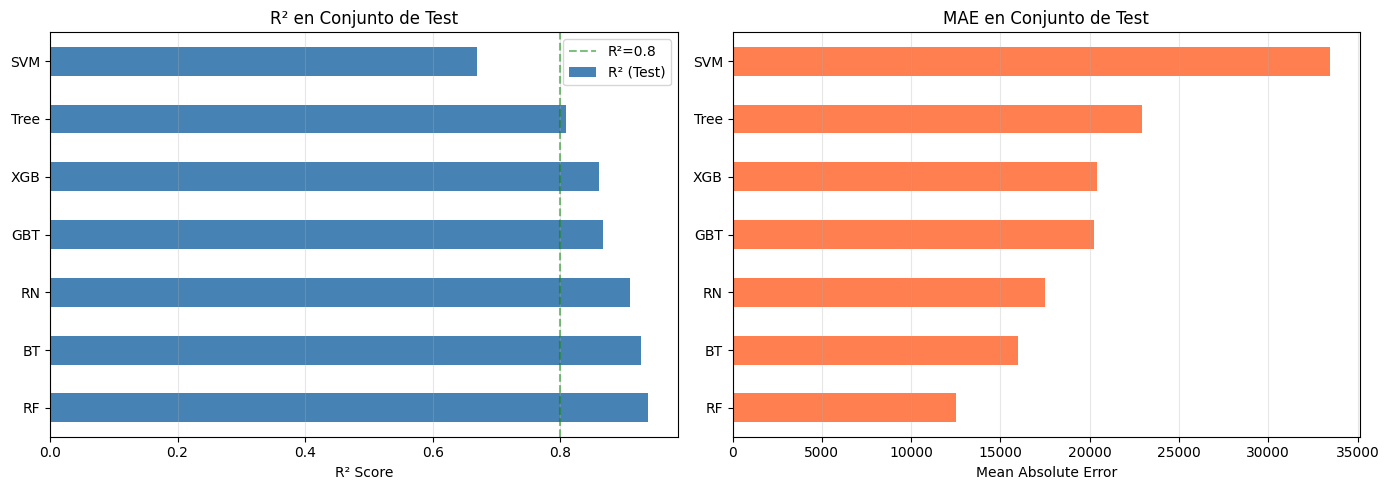

In [ ]:
# Evaluación de modelos en conjunto de TEST
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

# Hacer predicciones en el conjunto de test
# Para árboles (datos sin normalizar)
y_pred_tree = modelTree.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_bt = model_boos.predict(X_test)
y_pred_gbt = model_gbc.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)

# Para RN y SVM (datos normalizados)
y_pred_rn_scaled = model_rn.predict(X_test_scaled)
y_pred_svm_scaled = model_svm.predict(X_test_scaled)

# Desnormalizar predicciones de RN y SVM para comparar en escala original
y_pred_rn = min_max_scaler_Y.inverse_transform(y_pred_rn_scaled.reshape(-1, 1)).ravel()
y_pred_svm = min_max_scaler_Y.inverse_transform(y_pred_svm_scaled.reshape(-1, 1)).ravel()

# Calcular R² en test
r2_test = {
    'Tree': r2_score(Y_test, y_pred_tree),
    'RF': r2_score(Y_test, y_pred_rf),
    'BT': r2_score(Y_test, y_pred_bt),
    'GBT': r2_score(Y_test, y_pred_gbt),
    'XGB': r2_score(Y_test, y_pred_xgb),
    'RN': r2_score(Y_test, y_pred_rn),
    'SVM': r2_score(Y_test, y_pred_svm)
}

# Calcular MAE en test
mae_test = {
    'Tree': mean_absolute_error(Y_test, y_pred_tree),
    'RF': mean_absolute_error(Y_test, y_pred_rf),
    'BT': mean_absolute_error(Y_test, y_pred_bt),
    'GBT': mean_absolute_error(Y_test, y_pred_gbt),
    'XGB': mean_absolute_error(Y_test, y_pred_xgb),
    'RN': mean_absolute_error(Y_test, y_pred_rn),
    'SVM': mean_absolute_error(Y_test, y_pred_svm)
}

# Crear DataFrame con resultados
test_results = pd.DataFrame({
    'R² (Test)': r2_test,
    'MAE (Test)': mae_test
})

# Ordenar por R² descendente
test_results = test_results.sort_values('R² (Test)', ascending=False)


print("EVALUACIÓN EN CONJUNTO DE TEST (30%)")

display(test_results)

# Visualización
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de R²
test_results['R² (Test)'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² en Conjunto de Test')
axes[0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='R²=0.8')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Gráfico de MAE
test_results['MAE (Test)'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('Mean Absolute Error')
axes[1].set_title('MAE en Conjunto de Test')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


<Axes: >

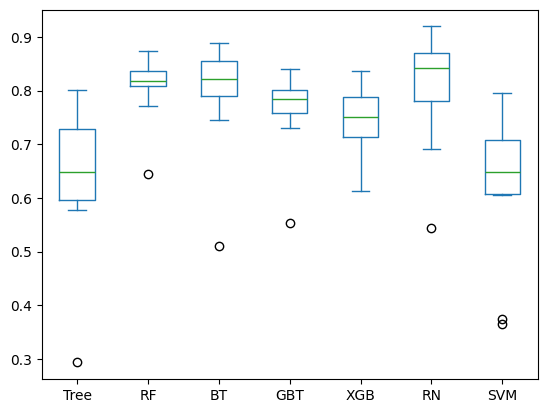

In [ ]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='box')

# 4. Guardamos el modelo

In [ ]:
import pickle

# Definir qué guardar
datos_hiperparametrizacion = {
    # Modelos seleccionados
    'models': {
        'boosting': model_boos,
        'random_forest': model_rf,
        'red_neuronal': model_rn
    },

    # Datos sin normalizar (para Boosting y RF)
    'data_raw': {
        'X_train': X_train,
        'X_test': X_test,
        'Y_train': Y_train,
        'Y_test': Y_test,
        'X_full': X,
        'Y_full': Y
    },

    # Datos normalizados (para Red Neuronal)
    'data_scaled': {
        'X_train_scaled': X_train_scaled,
        'X_test_scaled': X_test_scaled,
        'Y_train_scaled': Y_train_scaled,
        'Y_test_scaled': Y_test_scaled,
        'X_full_scaled': X_full_scaled,
        'Y_full_scaled': Y_scaled
    },

    # Scalers para normalización
    'scalers': {
        'scaler_X': min_max_scaler_X,
        'scaler_Y': min_max_scaler_Y,
        'var_num': var_num  # Lista de variables a normalizar
    },

    # Configuración de validación
    'config': {
        'cv': cv,  # 10
        'scoring': scoring,  # ('neg_mean_absolute_error', 'r2', etc.)
        'test_size': 0.3,
        'random_state': 42
    }
}

# Guardar
filename = 'hp_modelos_gs.pkl'
with open(filename, 'wb') as file:
    pickle.dump(datos_hiperparametrizacion, file)

